# Case

**Objetivo:** Análise exploratória e de correlação dos dados de campanhas de marketing da Omie, com foco em performance de canais, eficiência do funil de aquisição e alocação de verba.

**Contexto de negócio:** O departamento de Growth precisa gerar crescimento de 10% em NMRR (New Monthly Recurring Revenue) até dez/2023, com orçamento limitado.

**Etapas do funil (topo -> fundo):**
Impressões -> Cliques -> Sessões -> Formulários Enviados -> Lead -> Atribuído -> Agendamentos -> Conquistados -> Apps Pagos

**Período dos dados:** Janeiro a Dezembro de 2022

**O que está sendo feito:**
- Estruturação de uma análise completa, da auditoria dos dados até recomendações executivas.
- Avaliação de volume, conversão e eficiência por canal, grupo e tipo de campanha.

**Por que isso importa:**
- Gera uma linha de raciocínio clara para justificar decisões de investimento.
- Facilita para o entrevistador entender método, evidência e conclusão em sequência.


---
## 1. Importação de Bibliotecas

**O que está sendo feito:**
- Importação de bibliotecas para manipulação de dados, visualização, estatística e consumo de API.

**Por que isso importa:**
- Garante base técnica consistente para executar todas as etapas sem retrabalho.


In [1]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Requisições HTTP - API de câmbio do BCB
import requests

# Testes estatísticos para correlação
from scipy import stats

# Tratamento de encoding em nomes de campanha
from urllib.parse import unquote

# Utilitários
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

# Configurações visuais
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})
sns.set_style('whitegrid')
sns.set_palette('tab10')

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


---
## 2. Carregamento dos Dados

**O que está sendo feito:**
- Leitura das bases principais (`data.csv` e `campaigns.csv`) e preparação inicial para análise.

**Por que isso importa:**
- Define a matéria-prima do estudo e reduz risco de erro por leitura incorreta de arquivo.


In [2]:
# Carregar os dados
df_campaigns = pd.read_csv('docs/campaigns.csv')
df_data = pd.read_csv('docs/data.csv')

# Verificar o que foi carregado
print(f'campaigns: {df_campaigns.shape[0]} linhas x {df_campaigns.shape[1]} colunas')
print(f'data:      {df_data.shape[0]} linhas x {df_data.shape[1]} colunas')

print(f'\nColunas campaigns: {list(df_campaigns.columns)}')
print(f'Colunas data:      {list(df_data.columns)}')


campaigns: 815 linhas x 4 colunas
data:      233141 linhas x 4 colunas

Colunas campaigns: ['campanha', 'tipo_campanha', 'canal', 'grupo']
Colunas data:      ['data', 'campanha', 'metrica', 'valor']


---
## 3. Auditoria Inicial das Bases

**O que está sendo feito:**
- Diagnóstico inicial de estrutura, tipos, volume e qualidade dos dados recebidos.

**Por que isso importa:**
- Evita que inconsistências de origem contaminem métricas e conclusões posteriores.


In [3]:
# Auditoria: campaigns
print('=' * 60)
print('CAMPAIGNS')
print('=' * 60)

print(f'\nShape: {df_campaigns.shape[0]} linhas x {df_campaigns.shape[1]} colunas')
print(f'\nTipos de dados:\n{df_campaigns.dtypes}')
print(f'\nValores nulos:\n{df_campaigns.isnull().sum()}')
print(f'\nLinhas duplicadas: {df_campaigns.duplicated().sum()}')

print(f'\nValores únicos por coluna:')
for col in df_campaigns.columns:
    print(f'  {col}: {df_campaigns[col].nunique()}')

print(f'\nCanais: {sorted(df_campaigns["canal"].unique())}')
print(f'\nGrupos: {sorted(df_campaigns["grupo"].unique())}')

CAMPAIGNS

Shape: 815 linhas x 4 colunas

Tipos de dados:
campanha         str
tipo_campanha    str
canal            str
grupo            str
dtype: object

Valores nulos:
campanha         4
tipo_campanha    0
canal            0
grupo            0
dtype: int64

Linhas duplicadas: 6

Valores únicos por coluna:
  campanha: 808
  tipo_campanha: 42
  canal: 14
  grupo: 4

Canais: ['Afiliados', 'CRM', 'Criteo', 'Direto', 'Google Ads', 'Kwai Ads', 'LinkedIn Ads', 'Meta Ads', 'Microsoft Advertising', 'Referral', 'Seedtag', 'Taboola', 'TikTok Ads', 'Weach']

Grupos: ['CRM', 'Direto', 'Pago', 'Referral']


In [4]:
# Auditoria: data
print('=' * 60)
print('DATA')
print('=' * 60)

print(f'\nShape: {df_data.shape[0]} linhas x {df_data.shape[1]} colunas')
print(f'\nTipos de dados:\n{df_data.dtypes}')
print(f'\nValores nulos:\n{df_data.isnull().sum()}')
print(f'\nLinhas duplicadas: {df_data.duplicated().sum()}')

print(f'\nLinhas totalmente vazias: {df_data.isnull().all(axis=1).sum()}')

print(f'\nMétricas disponiveis: {sorted(df_data["metrica"].dropna().unique())}')
print(f'\nDistribuição de métricas:')
print(df_data['metrica'].value_counts())

DATA

Shape: 233141 linhas x 4 colunas

Tipos de dados:
data        str
campanha    str
metrica     str
valor       str
dtype: object

Valores nulos:
data        13615
campanha    13980
metrica     13615
valor       13615
dtype: int64

Linhas duplicadas: 13614

Linhas totalmente vazias: 13615

Métricas disponiveis: ['agendamento', 'apps_pagos', 'atribuidos', 'clicks', 'faturamento', 'formulario_enviado', 'impressoes', 'investimentos', 'lead', 'sessoes', 'vendas']

Distribuição de métricas:
metrica
sessoes               48661
formulario_enviado    45994
lead                  31792
atribuidos            24881
agendamento           18945
vendas                18240
apps_pagos            14295
faturamento           14226
investimentos          1090
clicks                  701
impressoes              701
Name: count, dtype: int64


### 3.1 Qualidade do JOIN entre tabelas

In [ ]:

# Diagnóstico de join: compara campanhas cadastradas vs campanhas presentes nos dados,
# identifica campanhas órfãs e mede o volume de registros afetados.
def diagnosticar_join(df_camps, df_dados):
    """Calcula e exibe cobertura do join. Retorna set de campanhas órfãs."""
    cadastradas = set(df_camps['campanha'].dropna().unique())
    nos_dados = set(df_dados['campanha'].dropna().unique())
    orfas = nos_dados - cadastradas
    n_orfaos = df_dados[df_dados['campanha'].isin(orfas)].shape[0]

    print(f"Campanhas no dicionário: {len(cadastradas)}")
    print(f"Campanhas nos dados:     {len(nos_dados)}")
    print(f"Match (em ambas):        {len(cadastradas & nos_dados)}")
    print(f"Só no dicionário:        {len(cadastradas - nos_dados)}")
    print(f"Só nos dados (órfãs):    {len(orfas)}")
    print(f"\nRegistros órfãos: {n_orfaos} ({n_orfaos / len(df_dados) * 100:.1f}% da base)")

    return orfas

campanhas_orfas = diagnosticar_join(df_campaigns, df_data)

Campanhas no dicionário: 808
Campanhas nos dados:     805
Match (em ambas):        449
Só no dicionário:        359
Só nos dados (órfãs):    356

Registros órfãos: 76221 (32.7% da base)


---
## 4. Limpeza, Padronização e Enriquecimento

Pipeline de remoção de registros inválidos, conversão de tipos, mapeamento de campanhas órfãs e padronização de nomes.

### 4.1 Remoção de linhas vazias e duplicatas

In [ ]:

# Fluxo da etapa: contabiliza base original, remove linhas vazias/duplicadas e
# valida o impacto da limpeza no volume final de registros.
n_bruto = len(df_data)
n_vazias = int(df_data.isnull().all(axis=1).sum())
n_dupl_camps = int(df_campaigns.duplicated().sum())

# Limpar: remover linhas totalmente vazias e depois duplicatas
df_data = df_data.dropna(how='all').drop_duplicates().reset_index(drop=True)
df_campaigns = df_campaigns.drop_duplicates().reset_index(drop=True)

print(f'df_data:      {n_bruto:,} → {len(df_data):,} (removidas {n_bruto - len(df_data):,} — {n_vazias:,} vazias + restante duplicadas)')
print(f'df_campaigns: removidas {n_dupl_camps} duplicadas → {len(df_campaigns):,} linhas')

df_data:      233,141 → 219,526 (removidas 13,615 — 13,615 vazias + restante duplicadas)
df_campaigns: removidas 6 duplicadas → 809 linhas


### 4.2 Parsing de datas e tipos

In [ ]:

# Parsing temporal: converte 'data' para datetime, cria chaves auxiliares
# (ano_mes, mes, nome_mes) e valida cobertura/calendário após conversão.
df_data['data'] = pd.to_datetime(df_data['data'], format='%m/%d/%Y')

# Colunas auxiliares para facilitar agregações temporais
df_data['ano_mes'] = df_data['data'].dt.to_period('M')
df_data['mes'] = df_data['data'].dt.month
df_data['nome_mes'] = df_data['data'].dt.strftime('%b')

# Validação do range de datas
print(f"Range de datas: {df_data['data'].min().date()} a {df_data['data'].max().date()}")
print(f"Dias únicos: {df_data['data'].dt.date.nunique()}")
print(f"Meses: {sorted(df_data['mes'].unique().tolist())}")
print(f"\nTipos após conversão:\n{df_data.dtypes}")

Range de datas: 2022-01-01 a 2022-12-31
Dias únicos: 365
Meses: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Tipos após conversão:
data        datetime64[us]
campanha               str
metrica                str
valor                  str
ano_mes          period[M]
mes                  int32
nome_mes               str
dtype: object


### 4.3 Parsing do investimento (EUR)

In [8]:
# Converte strings para float
# Investimentos vêm no formato europeu "€ 8,50" (vírgula = decimal)
# Demais métricas são inteiros simples como "5500"

# Regra de parsing: normaliza símbolo de moeda e separadores do formato europeu
# (milhar com ponto, decimal com vírgula); valores inválidos retornam NaN.
def parse_valor(val):
    """Converte string de valor para float.
    Trata formato EUR ('€ 8,50') e números simples ('5500').
    """
    if pd.isna(val) or str(val).strip() == '':
        return np.nan
    
    val = str(val).replace('€', '').replace('\u20ac', '').strip()
    
    # Formato europeu: ponto = milhar, vírgula = decimal (ex: "1.234,56")
    if ',' in val and '.' in val:
        val = val.replace('.', '').replace(',', '.')
    elif ',' in val:
        val = val.replace(',', '.')
    
    try:
        return float(val)
    except ValueError:
        return np.nan

# Aplica o parsing linha a linha para padronizar a coluna numérica 'valor_num'.
df_data['valor_num'] = df_data['valor'].apply(parse_valor)

# Validação: investimentos devem ter sido convertidos corretamente
inv = df_data[df_data['metrica'] == 'investimentos']
print(f"Investimentos: {len(inv)} registros")
print(f"  Soma EUR:  {inv['valor_num'].sum():,.2f}")
print(f"  Min:       {inv['valor_num'].min():,.2f}")
print(f"  Max:       {inv['valor_num'].max():,.2f}")
print(f"  Nulos:     {inv['valor_num'].isna().sum()}")
print(f"\nvalor_num nulos total: {df_data['valor_num'].isna().sum()}")

Investimentos: 1090 registros
  Soma EUR:  107,573.70
  Min:       0.00
  Max:       5,566.10
  Nulos:     0

valor_num nulos total: 0


### 4.4 Mapeamento de campanhas órfãs

In [9]:

# Classifica cada campanha órfã por heurísticas de nome para inferir
# tipo_campanha, canal e grupo antes do merge com o dicionário.
def classificar_campanha_orfa(nome):
    """Infere canal, grupo e tipo_campanha pelo padrão do nome da campanha."""
    if pd.isna(nome):
        return pd.Series({'tipo_campanha': 'Desconhecido', 'canal': 'Direto', 'grupo': 'Direto'})
    
    nome_decoded = unquote(str(nome)).upper()
    
    # CRM — padrão: CRM_pme_*
    if nome.startswith('CRM_') or 'CRM_PME' in nome_decoded:
        canal, grupo = 'CRM', 'CRM'
        if 'ABANDONO' in nome_decoded:
            tipo = 'CRM Abandono'
        elif 'CHURN' in nome_decoded:
            tipo = 'CRM Churn'
        elif 'CHATBOT' in nome_decoded:
            tipo = 'CRM Chatbot'
        else:
            tipo = 'CRM Aquisição'
        return pd.Series({'tipo_campanha': tipo, 'canal': canal, 'grupo': grupo})
    
    # Meta Ads — padrão: contém "facebook" ou "meta"
    if 'FACEBOOK' in nome_decoded or 'META' in nome_decoded:
        return pd.Series({
            'tipo_campanha': 'Facebook Conversão Aquisição',
            'canal': 'Meta Ads', 'grupo': 'Pago'
        })
    
    # Google PMax — padrão: contém "pmax" ou "performance_max"
    if 'PMAX' in nome_decoded or 'PERFORMANCE_MAX' in nome_decoded:
        return pd.Series({
            'tipo_campanha': 'Google PMax Aquisição',
            'canal': 'Google Ads', 'grupo': 'Pago'
        })
    
    # Referral — padrão: contém "blog" ou "parceiro"
    if 'BLOG' in nome_decoded or 'PARCEIRO' in nome_decoded:
        return pd.Series({
            'tipo_campanha': 'Blog', 'canal': 'Referral', 'grupo': 'Referral'
        })
    
    # Default: Direto
    return pd.Series({'tipo_campanha': 'Direto', 'canal': 'Direto', 'grupo': 'Direto'})

# Aplicar classificação nas campanhas órfãs (excluir possível header "campanha")
orfas = sorted(campanhas_orfas - {'campanha'})
df_orfas = pd.DataFrame({'campanha': orfas})
df_orfas[['tipo_campanha', 'canal', 'grupo']] = df_orfas['campanha'].apply(classificar_campanha_orfa)

print(f"Campanhas órfãs classificadas: {len(df_orfas)}")
print(f"\nDistribuição por canal:")
print(df_orfas['canal'].value_counts().to_string())

# Concatenar ao dicionário de campanhas
df_campaigns = pd.concat([df_campaigns, df_orfas], ignore_index=True)
df_campaigns = df_campaigns.drop_duplicates(subset='campanha').reset_index(drop=True)

# Revalidar cobertura do join
print(f"\n--- Após mapeamento ---")
diagnosticar_join(df_campaigns, df_data)

Campanhas órfãs classificadas: 356

Distribuição por canal:
canal
CRM           330
Meta Ads       22
Direto          2
Referral        1
Google Ads      1

--- Após mapeamento ---
Campanhas no dicionário: 1164
Campanhas nos dados:     805
Match (em ambas):        805
Só no dicionário:        359
Só nos dados (órfãs):    0

Registros órfãos: 0 (0.0% da base)


set()

### 4.5 Padronização de encoding nos tipos de campanha

In [ ]:
# Objetivo da célula: normalizar texto (URL encoding), corrigir typos de nomenclatura
# e tratar valores corrompidos antes das validações finais de distribuição.
# Problemas encontrados: URL encoding (%C3%A7 = ç), typos e variações de nome

# 1. Decodificar URL encoding em colunas de texto
for col in ['campanha', 'tipo_campanha']:
    df_campaigns[col] = df_campaigns[col].apply(
        lambda x: unquote(str(x)) if pd.notna(x) else x
    )

# 2. Corrigir typos e padronizar nomes
substituicoes = {
    'Google Dsiplay Aquisição': 'Google Display Aquisição',
    'Google Dsiplay Remarketing': 'Google Display Remarketing',
    'Google Pmax Aquisição': 'Google PMax Aquisição',
    'Google Search Brand Aquisição': 'Google Search Branded Aquisição',
    'Google Search Non Brand Aquisição': 'Google Search Non Branded Aquisição',
    'Bing Search Brand Aquisição': 'Bing Search Branded Aquisição',
    'Bing Search Brand Remarketing': 'Bing Search Branded Remarketing',
}
df_campaigns['tipo_campanha'] = df_campaigns['tipo_campanha'].replace(substituicoes)

# 3. Corrigir valor corrompido (Excel converteu número longo em notação científica)
mask_corrupto = df_campaigns['tipo_campanha'].str.contains('38527E', na=False)
if mask_corrupto.any():
    df_campaigns.loc[mask_corrupto, ['tipo_campanha', 'canal', 'grupo']] = ['Direto', 'Direto', 'Direto']
    print(f"Registros corrompidos corrigidos: {mask_corrupto.sum()}")

# Validação
print(f"\nTipos de campanha únicos: {df_campaigns['tipo_campanha'].nunique()}")
print(f"\nDistribuição de tipo_campanha:")
print(df_campaigns['tipo_campanha'].value_counts().to_string())


Tipos de campanha únicos: 36

Distribuição de tipo_campanha:
tipo_campanha
CRM Aquisição                          276
CRM Abandono                           256
Facebook Conversão Aquisição           140
CRM Churn                              131
Google Search Geral Aquisição          107
Google Search Non Branded Aquisição     34
Google PMax Aquisição                   33
Google Search Branded Aquisição         22
Facebook Conversão Remarketing          22
Google Display Remarketing              21
Blog                                    20
Bing Search Non Branded Aquisição       14
Google Search Geral Remarketing         13
Bing Search Branded Aquisição           12
Bing Search Geral Aquisição              9
Direto                                   8
Facebook WhatsApp Aquisição              6
Google Display Aquisição                 5
Google Discovery Aquisição               5
Google YouTube Aquisição                 4
Bing Search Geral Remarketing            4
Bing Display Remarket

---
## 5. Conversão Cambial EUR -> BRL via API

Conversão dos investimentos de EUR para BRL usando cotações diárias PTAX do Banco Central.

### 5.1 Identificar datas com investimento

In [ ]:

# Isola apenas registros de investimentos e extrai as datas únicas com investimento
# para definir o calendário efetivo usado na etapa de câmbio.
df_investimentos = df_data[df_data['metrica'] == 'investimentos'].copy()

datas_investimento = sorted(df_investimentos['data'].dt.date.unique())
print(f"Registros de investimento: {len(df_investimentos)}")
print(f"Datas únicas com investimento: {len(datas_investimento)}")
print(f"Período: {datas_investimento[0]} a {datas_investimento[-1]}")

Registros de investimento: 1090
Datas únicas com investimento: 344
Período: 2022-01-02 a 2022-12-31


### 5.2 Buscar taxas de câmbio via API do Banco Central

In [ ]:

# Consulta a PTAX EUR/BRL para o período do case e apresenta resumo estatístico
# das cotações obtidas para validar cobertura temporal.
# A API retorna cotações apenas para dias úteis (PTAX venda = taxa de fechamento)

# Recebe intervalo (data_inicial/data_final), consulta endpoint OData do BCB
# e devolve dict {data: cotacao_venda} para uso no mapeamento diário.
def buscar_taxas_eur_brl(data_inicial='01-01-2022', data_final='12-31-2022'):
    """Busca cotações diárias EUR/BRL via API PTAX do Banco Central do Brasil."""
    url = (
        "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
        "CotacaoMoedaPeriodo(moeda=@moeda,dataInicial=@dataInicial,"
        "dataFinalCotacao=@dataFinalCotacao)"
    )
    params = {
        '@moeda': "'EUR'",
        '@dataInicial': f"'{data_inicial}'",
        '@dataFinalCotacao': f"'{data_final}'",
        '$top': '10000',
        '$format': 'json',
        '$select': 'cotacaoVenda,dataHoraCotacao'
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    dados = response.json()['value']
    
    # Converter para dict {date: taxa_venda}
    taxas = {}
    for item in dados:
        dt = pd.to_datetime(item['dataHoraCotacao']).date()
        taxas[dt] = item['cotacaoVenda']
    
    return taxas

taxas_eur_brl = buscar_taxas_eur_brl()

print(f"Cotações obtidas: {len(taxas_eur_brl)} dias úteis")
print(f"Período: {min(taxas_eur_brl.keys())} a {max(taxas_eur_brl.keys())}")
print(f"Taxa média: {np.mean(list(taxas_eur_brl.values())):.4f}")
print(f"Taxa min:   {min(taxas_eur_brl.values()):.4f}")
print(f"Taxa max:   {max(taxas_eur_brl.values()):.4f}")

Cotações obtidas: 251 dias úteis
Período: 2022-01-03 a 2022-12-30
Taxa média: 5.4420
Taxa min:   4.9841
Taxa max:   6.4435


### 5.3 Aplicar conversão EUR -> BRL

Investimento total EUR:   107,573.70
Investimento total BRL:   576,231.35
Taxa média usada:             5.2767
Registros sem taxa:     0


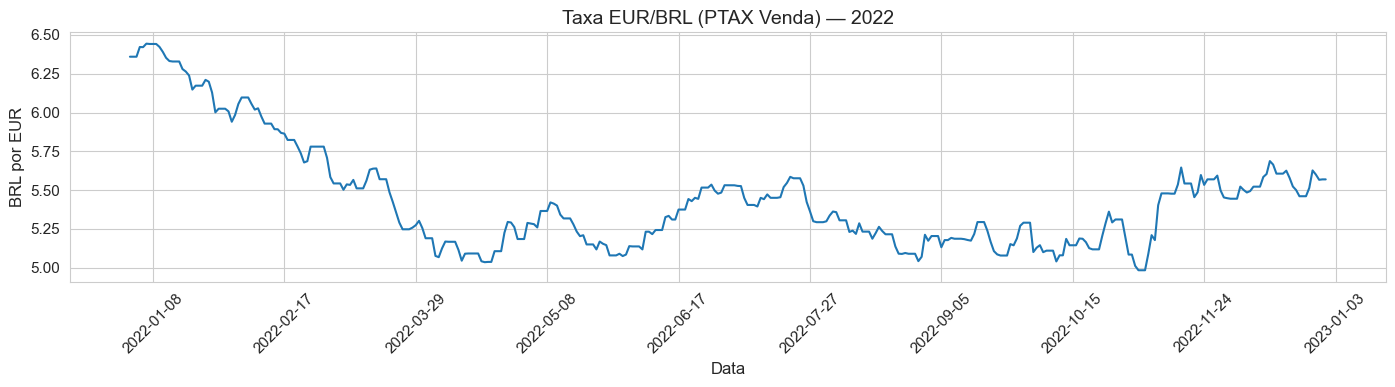

In [ ]:
# Para fins de semana e feriados, usamos a taxa do último dia útil (forward fill)

# Criar série de taxas para todos os 365 dias de 2022
todos_os_dias = pd.date_range('2022-01-01', '2022-12-31', freq='D')
df_taxas = pd.Series(taxas_eur_brl).reindex(
    [d.date() for d in todos_os_dias]
).ffill().bfill()

# Mapear taxa para cada registro
df_data['taxa_eur_brl'] = df_data['data'].dt.date.map(df_taxas)

# Calcular valor em BRL:
# - Investimentos: valor_num * taxa (conversão EUR → BRL)
# - Demais métricas: mantém valor_num original (já estão na unidade correta)
df_data['valor_brl'] = np.where(
    df_data['metrica'] == 'investimentos',
    df_data['valor_num'] * df_data['taxa_eur_brl'],
    df_data['valor_num']
)

# Validação
inv = df_data[df_data['metrica'] == 'investimentos']
print(f"Investimento total EUR: {inv['valor_num'].sum():>12,.2f}")
print(f"Investimento total BRL: {inv['valor_brl'].sum():>12,.2f}")
print(f"Taxa média usada:       {inv['taxa_eur_brl'].mean():>12.4f}")
print(f"Registros sem taxa:     {inv['taxa_eur_brl'].isna().sum()}")

# Gráfico: evolução da taxa EUR/BRL em 2022
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_taxas.index, df_taxas.values, color='tab:blue', linewidth=1.5)
ax.set_title('Taxa EUR/BRL (PTAX Venda) — 2022')
ax.set_xlabel('Data')
ax.set_ylabel('BRL por EUR')
ax.xaxis.set_major_locator(mticker.MaxNLocator(12))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 6. Construção da Base Analítica

**O que está sendo feito:**
- Consolidação das colunas necessárias para análises de funil, canal e custo.

**Por que isso importa:**
- Cria uma visão única, reduzindo complexidade e risco de divergência entre etapas.


In [ ]:
# Cada linha será uma combinação de data + campanha com todas as métricas como colunas

# 1. Pivotar: uma coluna para cada métrica
df_pivot = df_data.pivot_table(
    index=['data', 'campanha', 'ano_mes', 'mes'],
    columns='metrica',
    values='valor_brl',
    aggfunc='sum'
).reset_index()

df_pivot.columns.name = None

# 2. Renomear colunas para nomes padronizados do funil
renomear_colunas = {
    'clicks': 'cliques',
    'formulario_enviado': 'formularios_enviados',
    'lead': 'leads',
    'agendamento': 'agendamentos',
    'vendas': 'conquistados',
    'investimentos': 'investimento_brl',
}
df_pivot = df_pivot.rename(columns=renomear_colunas)

# 3. Adicionar investimento em EUR (referência)
inv_eur = df_data[df_data['metrica'] == 'investimentos'].pivot_table(
    index=['data', 'campanha'],
    values='valor_num',
    aggfunc='sum'
).rename(columns={'valor_num': 'investimento_eur'}).reset_index()

df_pivot = df_pivot.merge(inv_eur, on=['data', 'campanha'], how='left')

# 4. Merge com campaigns para trazer canal, grupo, tipo_campanha
df_pivot = df_pivot.merge(
    df_campaigns[['campanha', 'tipo_campanha', 'canal', 'grupo']],
    on='campanha',
    how='left'
)

# 5. Preencher NaN de métricas numéricas com 0
metricas_cols = [
    'impressoes', 'cliques', 'sessoes', 'formularios_enviados',
    'leads', 'atribuidos', 'agendamentos', 'conquistados',
    'apps_pagos', 'faturamento', 'investimento_brl', 'investimento_eur'
]
for col in metricas_cols:
    if col in df_pivot.columns:
        df_pivot[col] = df_pivot[col].fillna(0)

# Validação
print(f"Shape: {df_pivot.shape}")
print(f"Colunas: {list(df_pivot.columns)}")
print(f"Cobertura canal: {df_pivot['canal'].notna().mean():.1%}")
print(f"Canais: {sorted(df_pivot['canal'].dropna().unique().tolist())}")
print(f"\nAmostra:")
df_pivot.head(3)

Shape: (73545, 19)
Colunas: ['data', 'campanha', 'ano_mes', 'mes', 'agendamentos', 'apps_pagos', 'atribuidos', 'cliques', 'faturamento', 'formularios_enviados', 'impressoes', 'investimento_brl', 'leads', 'sessoes', 'conquistados', 'investimento_eur', 'tipo_campanha', 'canal', 'grupo']
Cobertura canal: 98.0%
Canais: ['Afiliados', 'CRM', 'Criteo', 'Direto', 'Google Ads', 'Kwai Ads', 'LinkedIn Ads', 'Meta Ads', 'Microsoft Advertising', 'Referral', 'Seedtag', 'Taboola', 'TikTok Ads', 'Weach']

Amostra:


,data,campanha,ano_mes,mes,agendamentos,apps_pagos,atribuidos,cliques,faturamento,formularios_enviados,impressoes,investimento_brl,leads,sessoes,conquistados,investimento_eur,tipo_campanha,canal,grupo
0,2022-01-01,0,2022-01,1,33.0,10.0,40.0,0.0,5500.0,171.0,0.0,0.0,73.0,0.0,33.0,0.0,Direto,Direto,Direto
1,2022-01-01,CRM_pme_Aquisicao_Planejamento_Comercial_Aband...,2022-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,CRM Abandono,CRM,CRM
2,2022-01-01,CRM_pme_Aquisicao_Planejamento_Comercial_Aband...,2022-01,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,CRM Abandono,CRM,CRM


### 6.1 Função auxiliar e definições

In [ ]:


# Helpers e definições-base usados nas análises/indicadores das próximas etapas.
# Evita divisões inválidas em métricas derivadas, retornando 0 quando o
# denominador é 0 ou NaN.
def safe_div(num, den):
    """Divisão segura: retorna 0 onde denominador é 0 ou NaN."""
    return np.where((den > 0) & (~np.isnan(den)), num / den, 0)

# Ordem do funil (topo → fundo), conforme definido no case
metricas_funil = [
    'impressoes', 'cliques', 'sessoes', 'formularios_enviados',
    'leads', 'atribuidos', 'agendamentos', 'conquistados', 'apps_pagos'
]

# Labels legíveis para gráficos
labels_funil = [
    'Impressões', 'Cliques', 'Sessões', 'Formulários',
    'Leads', 'Atribuídos', 'Agendamentos', 'Conquistados', 'Apps Pagos'
]

print("Funções auxiliares e definições carregadas.")

Funções auxiliares e definições carregadas.


---
## 7. Análise Exploratória

### 7.1 Performance Geral por Canal

**O que está sendo feito:**
- Comparação de canais por volume de leads, apps pagos e taxas de conversão.
- Identificação de canais com maior escala e canais com maior eficiência relativa.

**Por que isso importa:**
- Direciona priorização de canais que maximizam resultado com verba limitada.
- Separa canais de awareness de canais de fechamento para decisões mais precisas.


In [16]:
# Agregação de todas as métricas do funil + investimento por canal e calculamos indicadores de eficiência

canal_agg = df_pivot.groupby('canal').agg(
    impressoes=('impressoes', 'sum'),
    cliques=('cliques', 'sum'),
    sessoes=('sessoes', 'sum'),
    formularios_enviados=('formularios_enviados', 'sum'),
    leads=('leads', 'sum'),
    atribuidos=('atribuidos', 'sum'),
    agendamentos=('agendamentos', 'sum'),
    conquistados=('conquistados', 'sum'),
    apps_pagos=('apps_pagos', 'sum'),
    faturamento=('faturamento', 'sum'),
    investimento_brl=('investimento_brl', 'sum'),
).reset_index()

# Métricas derivadas de eficiência
canal_agg['ctr'] = safe_div(canal_agg['cliques'], canal_agg['impressoes'])
canal_agg['cvr_sessao_lead'] = safe_div(canal_agg['leads'], canal_agg['sessoes'])
canal_agg['cvr_lead_app'] = safe_div(canal_agg['apps_pagos'], canal_agg['leads'])
canal_agg['cpl'] = safe_div(canal_agg['investimento_brl'], canal_agg['leads'])
canal_agg['cpa'] = safe_div(canal_agg['investimento_brl'], canal_agg['apps_pagos'])

canal_agg = canal_agg.sort_values('investimento_brl', ascending=False)

# Exibir colunas mais relevantes
display_cols = ['canal', 'sessoes', 'leads', 'apps_pagos', 'investimento_brl',
                'cvr_sessao_lead', 'cvr_lead_app', 'cpl', 'cpa']
print("Performance por Canal:\n")
print(canal_agg[display_cols].to_string(index=False, float_format='{:,.2f}'.format))

Performance por Canal:

                canal      sessoes      leads  apps_pagos  investimento_brl  cvr_sessao_lead  cvr_lead_app   cpl    cpa
           Google Ads 1,555,306.00  76,516.00   20,090.00        363,376.92             0.05          0.26  4.75  18.09
                Weach   473,269.00   4,389.00    1,037.00        196,483.08             0.01          0.24 44.77 189.47
            Afiliados     5,881.00     433.00      113.00         13,915.52             0.07          0.26 32.14 123.15
Microsoft Advertising   128,341.00   2,410.00      751.00          2,412.10             0.02          0.31  1.00   3.21
             Referral    22,233.00   1,694.00      300.00             43.73             0.08          0.18  0.03   0.15
                  CRM   259,365.00  22,363.00    4,463.00              0.00             0.09          0.20  0.00   0.00
             Kwai Ads    42,992.00       7.00        0.00              0.00             0.00          0.00  0.00   0.00
               D

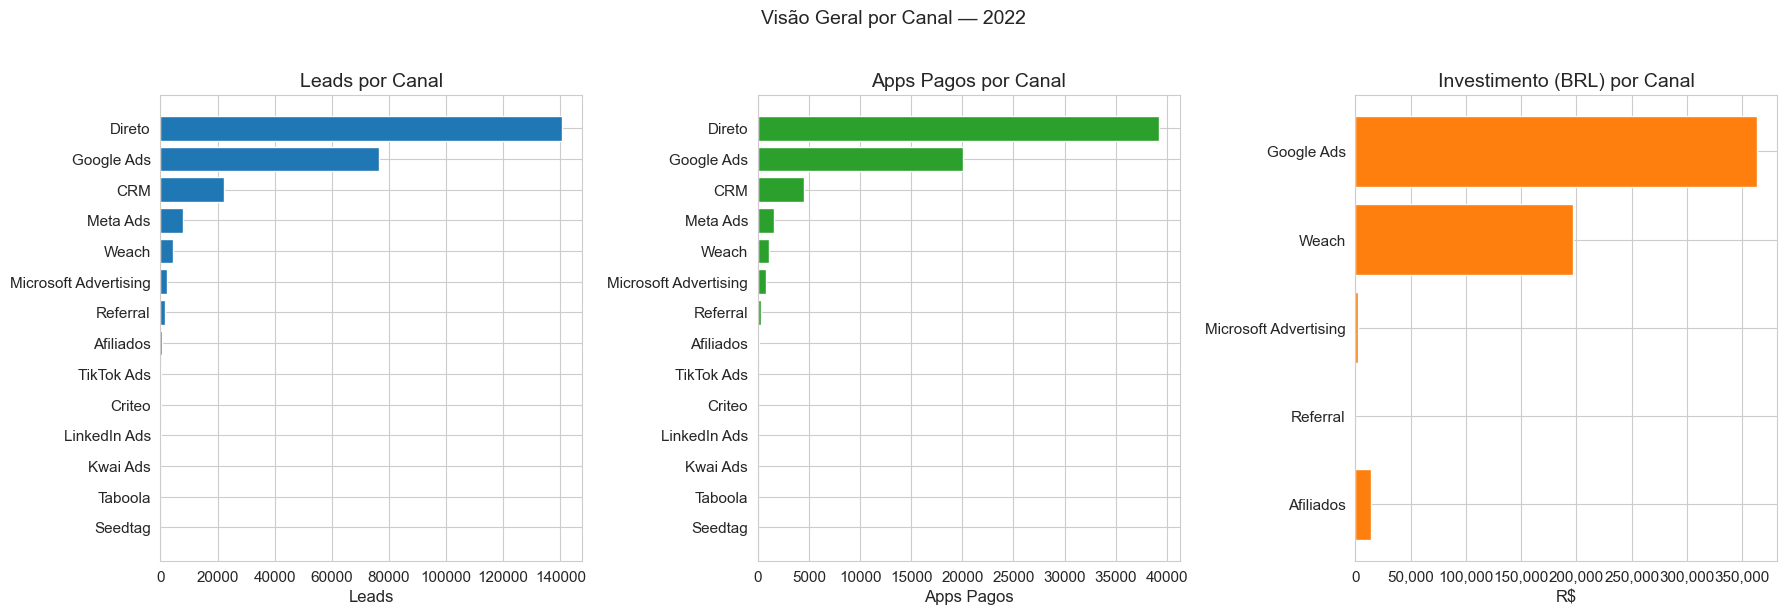

In [ ]:
# Visualização dos 3 indicadores principais para comparação rápida entre canais

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

canal_plot = canal_agg.sort_values('leads', ascending=True)

# Leads por canal
axes[0].barh(canal_plot['canal'], canal_plot['leads'], color='tab:blue')
axes[0].set_title('Leads por Canal')
axes[0].set_xlabel('Leads')

# Apps Pagos por canal
axes[1].barh(canal_plot['canal'], canal_plot['apps_pagos'], color='tab:green')
axes[1].set_title('Apps Pagos por Canal')
axes[1].set_xlabel('Apps Pagos')

# Investimento por canal (apenas canais pagos)
canal_inv = canal_plot[canal_plot['investimento_brl'] > 0].copy()
axes[2].barh(canal_inv['canal'], canal_inv['investimento_brl'], color='tab:orange')
axes[2].set_title('Investimento (BRL) por Canal')
axes[2].set_xlabel('R$')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Visão Geral por Canal — 2022', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Performance por Tipo de Campanha

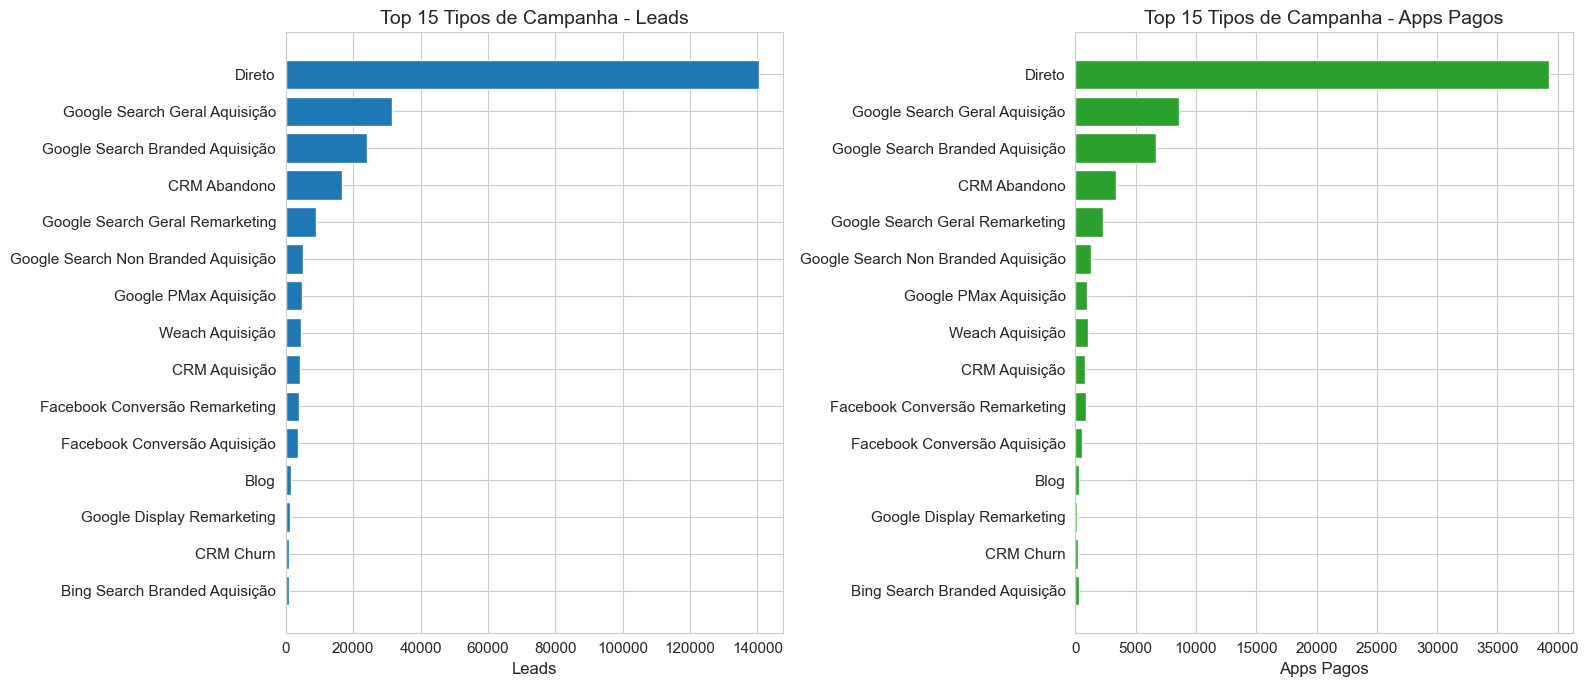

In [ ]:
# Top 15 tipos por volume de leads para ajudar a entender quais estratégias geram mais volume

tipo_agg = df_pivot.groupby('tipo_campanha').agg(
    leads=('leads', 'sum'),
    apps_pagos=('apps_pagos', 'sum'),
    investimento_brl=('investimento_brl', 'sum'),
    sessoes=('sessoes', 'sum'),
).reset_index()

tipo_agg['cvr_lead_app'] = safe_div(tipo_agg['apps_pagos'], tipo_agg['leads'])
tipo_agg['cpl'] = safe_div(tipo_agg['investimento_brl'], tipo_agg['leads'])

top_tipos = tipo_agg.nlargest(15, 'leads').sort_values('leads', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_tipos['tipo_campanha'], top_tipos['leads'], color='tab:blue')
axes[0].set_title('Top 15 Tipos de Campanha - Leads')
axes[0].set_xlabel('Leads')

axes[1].barh(top_tipos['tipo_campanha'], top_tipos['apps_pagos'], color='tab:green')
axes[1].set_title('Top 15 Tipos de Campanha - Apps Pagos')
axes[1].set_xlabel('Apps Pagos')

plt.tight_layout()
plt.show()

### 7.3 Performance por Grupo (Pago, CRM, Direto, Referral)

In [19]:
# Visão macro: quanto cada grupo contribui para o resultado total

grupo_agg = df_pivot.groupby('grupo').agg(
    sessoes=('sessoes', 'sum'),
    leads=('leads', 'sum'),
    apps_pagos=('apps_pagos', 'sum'),
    faturamento=('faturamento', 'sum'),
    investimento_brl=('investimento_brl', 'sum'),
).reset_index()

grupo_agg['cvr_sessao_lead'] = safe_div(grupo_agg['leads'], grupo_agg['sessoes'])
grupo_agg['cvr_lead_app'] = safe_div(grupo_agg['apps_pagos'], grupo_agg['leads'])
grupo_agg['cpl'] = safe_div(grupo_agg['investimento_brl'], grupo_agg['leads'])
grupo_agg['cpa'] = safe_div(grupo_agg['investimento_brl'], grupo_agg['apps_pagos'])
grupo_agg['share_leads'] = grupo_agg['leads'] / grupo_agg['leads'].sum()
grupo_agg['share_apps'] = grupo_agg['apps_pagos'] / grupo_agg['apps_pagos'].sum()

print("Performance por Grupo:\n")
print(grupo_agg.to_string(index=False, float_format='{:,.2f}'.format))

Performance por Grupo:

   grupo      sessoes      leads  apps_pagos   faturamento  investimento_brl  cvr_sessao_lead  cvr_lead_app  cpl   cpa  share_leads  share_apps
     CRM   259,365.00  22,363.00    4,463.00  2,183,500.00              0.00             0.09          0.20 0.00  0.00         0.09        0.07
  Direto    36,625.00 140,582.00   39,280.00 19,119,500.00              0.00             3.84          0.28 0.00  0.00         0.55        0.58
    Pago 2,817,894.00  91,642.00   23,555.00 11,518,000.00        576,187.62             0.03          0.26 6.29 24.46         0.36        0.35
Referral    22,233.00   1,694.00      300.00    146,500.00             43.73             0.08          0.18 0.03  0.15         0.01        0.00


---
## 8. Análise do Funil por Canal

Funil: Impressões -> Cliques -> Sessões -> Formulários -> Leads -> Atribuídos -> Agendamentos -> Conquistados -> Apps Pagos

**O que está sendo feito:**
- Medição de volume absoluto e taxa de passagem entre etapas consecutivas do funil por canal.
- Construção de duas visões normalizadas complementares para comparação justa de formato.
- Visão 1: canais pagos com base em Impressões = 100 (funil completo).
- Visão 2: todos os canais com base em Leads = 100 (foco em meio/fundo).
- Exposição transparente dos canais pagos excluídos da Visão 1 quando `impressões = 0`.

**Por que isso importa:**
- Evita comparar canais com bases de topo incompatíveis em um único gráfico.
- Separa a leitura de eficiência de aquisição paga (topo completo) da eficiência comercial (meio/fundo).
- Regra de interpretação: comparar formato relativo das curvas, sem inferir causalidade.


In [ ]:
# Funil por canal - volume absoluto
# Nota: impressões e cliques existem apenas para canais pagos com mídia display/search

funil_canal = df_pivot.groupby('canal')[metricas_funil].sum()
funil_canal = funil_canal.sort_values('leads', ascending=False)

print("Volume absoluto do funil por canal:\n")
print(funil_canal.to_string(float_format='{:,.0f}'.format))

Volume absoluto do funil por canal:

                       impressoes  cliques   sessoes  formularios_enviados   leads  atribuidos  agendamentos  conquistados  apps_pagos
canal                                                                                                                                 
Direto                          0        0    36,625               299,512 140,582      89,593        72,595        68,617      39,280
Google Ads             38,054,974  303,741 1,555,306               278,484  76,516      48,857        37,327        35,298      20,090
CRM                             0        0   259,365                62,083  22,363      13,918         9,696         9,005       4,463
Meta Ads                        0        0   505,877                38,186   7,757       4,641         3,195         2,976       1,547
Weach                           0        0   473,269                14,212   4,389       2,775         2,134         1,992       1,037
Microsoft Advertis

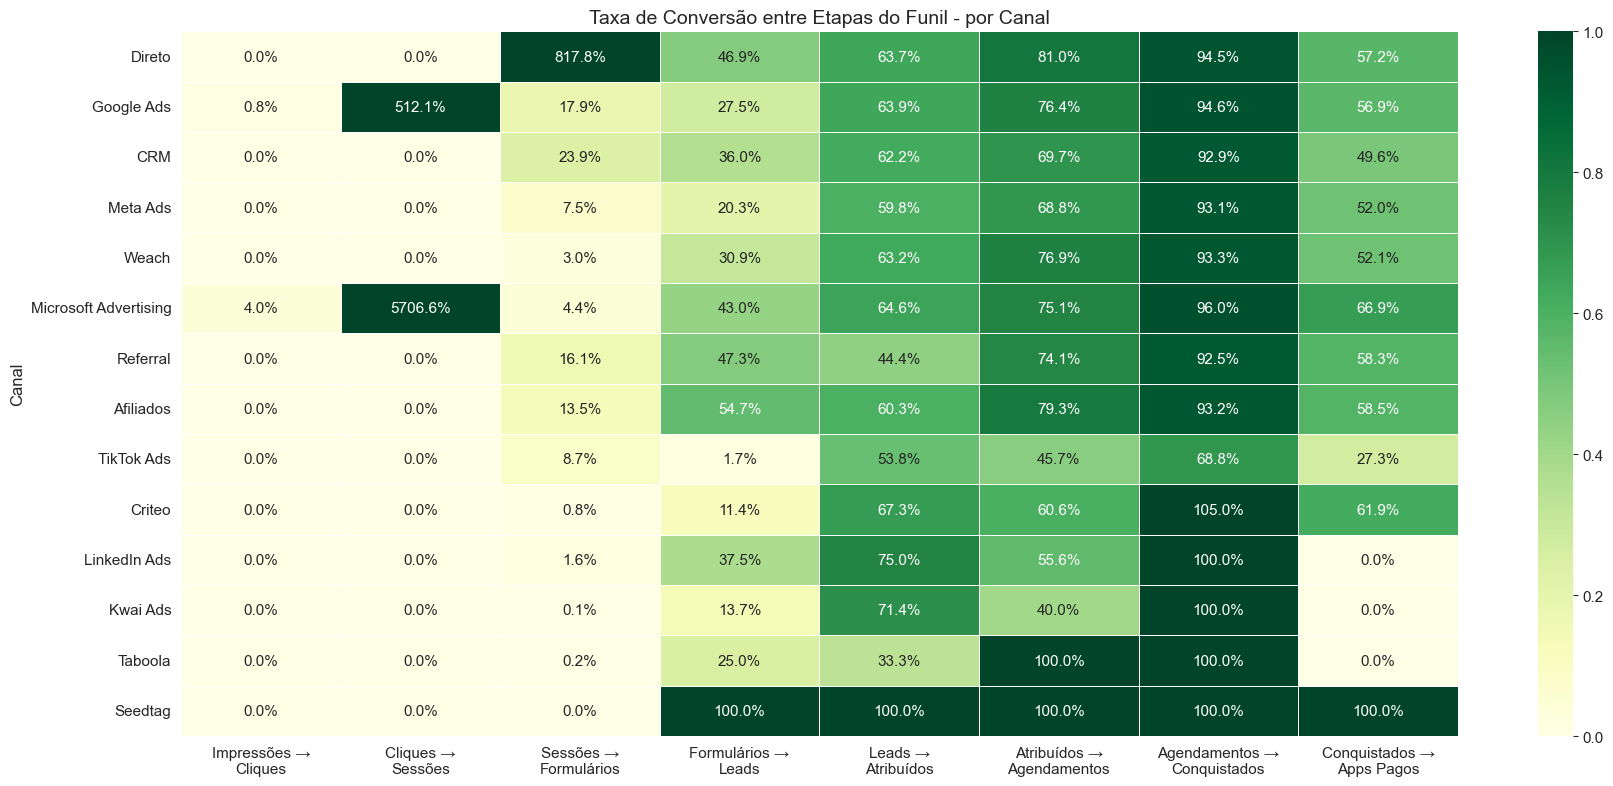

In [21]:
# Heatmap de conversão entre etapas consecutivas do funil
# Cada célula mostra a taxa de passagem de uma etapa para a próxima, por canal

taxas_funil = pd.DataFrame(index=funil_canal.index)
for i in range(len(metricas_funil) - 1):
    col_de = metricas_funil[i]
    col_para = metricas_funil[i + 1]
    label = f'{labels_funil[i]} →\n{labels_funil[i+1]}'
    taxas_funil[label] = safe_div(
        funil_canal[col_para].values, funil_canal[col_de].values
    )

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    taxas_funil, annot=True, fmt='.1%', cmap='YlGn',
    linewidths=0.5, ax=ax, vmin=0, vmax=1
)
ax.set_title('Taxa de Conversão entre Etapas do Funil - por Canal')
ax.set_ylabel('Canal')
plt.tight_layout()
plt.show()

Visão 1 - Canais pagos (base em Impressões = 100)
Canais incluídos: 2
Canais pagos excluídos (impressões = 0): Afiliados, Criteo, Kwai Ads, LinkedIn Ads, Meta Ads, Seedtag, Taboola, TikTok Ads, Weach


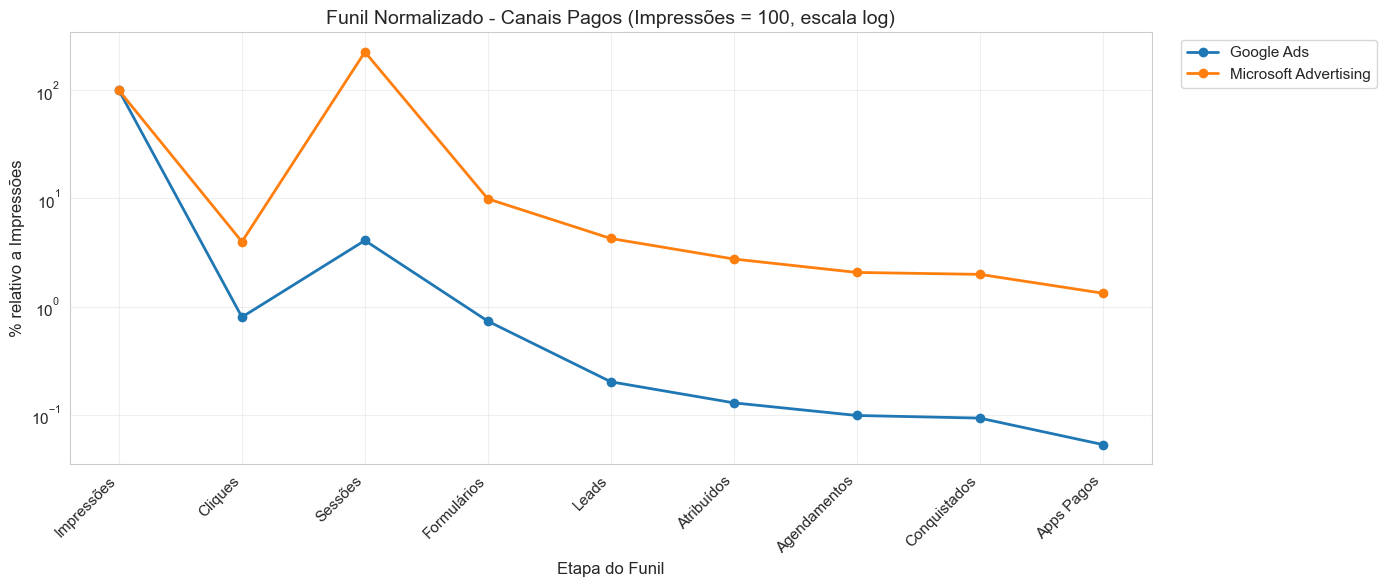


Visão 2 - Todos os canais (base em Leads = 100, meio/fundo)
Canais incluídos: 14


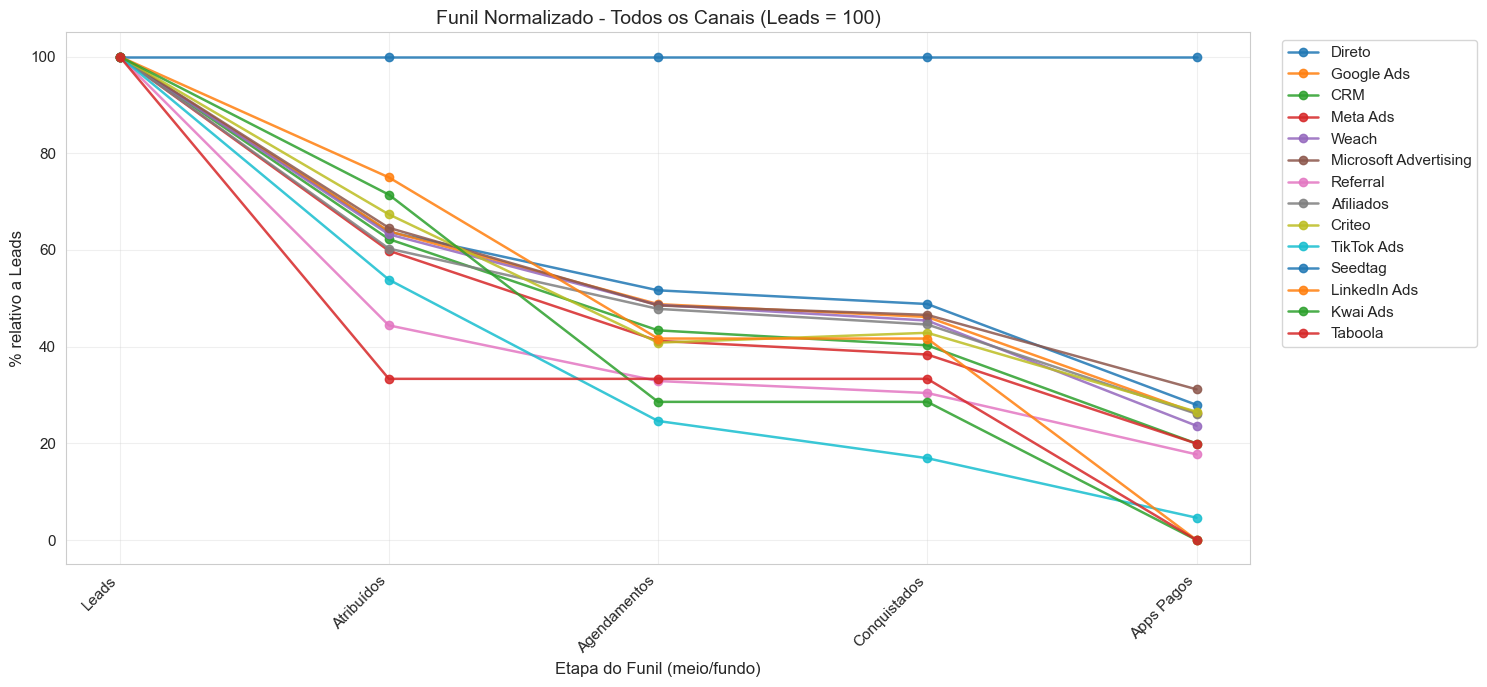

In [ ]:
# Funil normalizado 
# Visão 1: canais pagos com base em Impressões = 100 (funil completo)
# Visão 2: todos os canais com base em Leads = 100 (meio/fundo)

canal_grupo = (
    df_pivot[['canal', 'grupo']]
    .dropna(subset=['canal'])
    .drop_duplicates(subset=['canal'])
    .set_index('canal')['grupo']
)

funil_norm = funil_canal.copy()
funil_norm['grupo'] = funil_norm.index.map(canal_grupo)

# =============================
# Visão 1: Canais pagos (Impressões = 100)
# =============================
paid_all = funil_norm[funil_norm['grupo'] == 'Pago'].copy()
paid_valid = paid_all[paid_all['impressoes'] > 0].copy().sort_values('leads', ascending=False)
paid_excluidos = sorted(paid_all[paid_all['impressoes'] <= 0].index.tolist())

print('Visão 1 - Canais pagos (base em Impressões = 100)')
print(f'Canais incluídos: {len(paid_valid)}')
if paid_excluidos:
    print('Canais pagos excluídos (impressões = 0): ' + ', '.join(paid_excluidos))
else:
    print('Canais pagos excluídos (impressões = 0): nenhum')

if paid_valid.empty:
    print('Sem canais pagos com impressões > 0 para plotar.')
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    for canal, row in paid_valid.iterrows():
        valores = row[metricas_funil].values.astype(float)
        valores_norm = (valores / row['impressoes']) * 100
        ax.plot(labels_funil, valores_norm, marker='o', linewidth=2, label=canal)

    ax.set_yscale('log')
    ax.set_title('Funil Normalizado - Canais Pagos (Impressões = 100, escala log)')
    ax.set_ylabel('% relativo a Impressões')
    ax.set_xlabel('Etapa do Funil')
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# =============================
# Visão 2: Todos os canais (Leads = 100, meio/fundo)
# =============================
stages_meio_fundo = ['leads', 'atribuidos', 'agendamentos', 'conquistados', 'apps_pagos']
labels_meio_fundo = ['Leads', 'Atribuídos', 'Agendamentos', 'Conquistados', 'Apps Pagos']

todos_valid = funil_norm[funil_norm['leads'] > 0].copy().sort_values('apps_pagos', ascending=False)

print('\nVisão 2 - Todos os canais (base em Leads = 100, meio/fundo)')
print(f'Canais incluídos: {len(todos_valid)}')

if todos_valid.empty:
    print('Sem canais com leads > 0 para plotar.')
else:
    fig, ax = plt.subplots(figsize=(15, 7))

    for canal, row in todos_valid.iterrows():
        valores = row[stages_meio_fundo].values.astype(float)
        valores_norm = (valores / row['leads']) * 100
        ax.plot(labels_meio_fundo, valores_norm, marker='o', linewidth=1.8, alpha=0.85, label=canal)

    ax.set_title('Funil Normalizado - Todos os Canais (Leads = 100)')
    ax.set_ylabel('% relativo a Leads')
    ax.set_xlabel('Etapa do Funil (meio/fundo)')
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


---
## 9. Leads por Mês e Sazonalidade

**O que está sendo feito:**
- Leitura da evolução mensal de leads totais e por canal para detectar padrão sazonal.

**Por que isso importa:**
- Apoia planejamento de verba e metas por período, evitando comparações injustas entre meses.


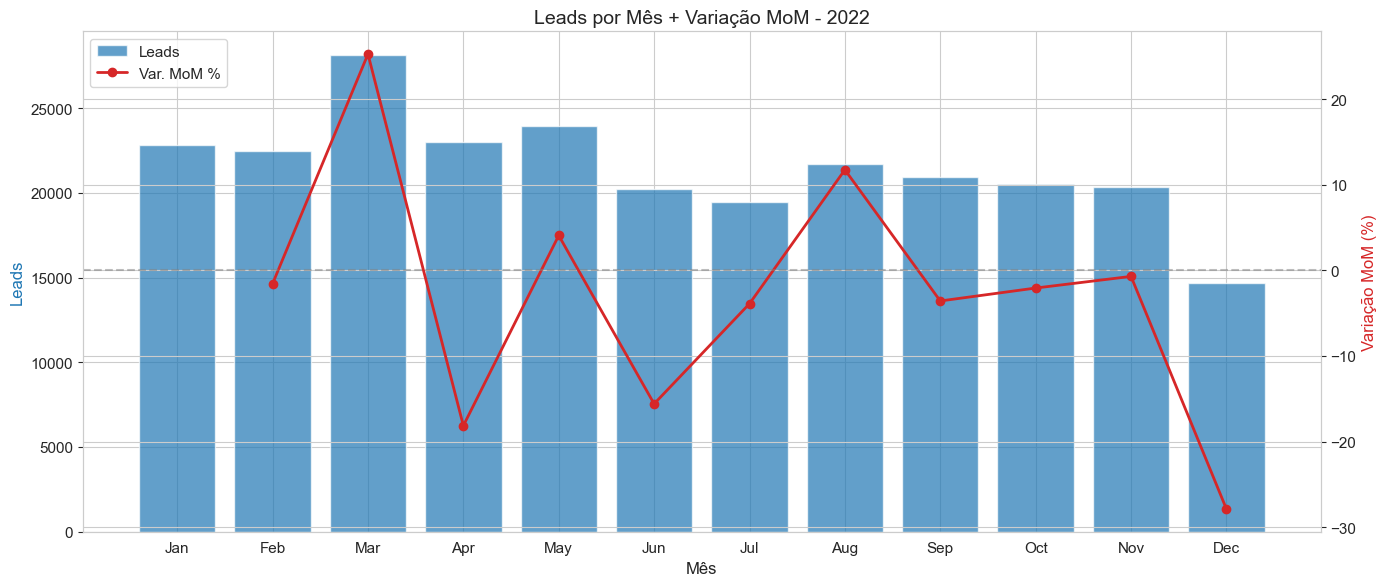

In [23]:
# Leads por mês + variação mês a mês (MoM)
# identificar padrões de sazonalidade na geração de leads

leads_mes = df_pivot.groupby('mes')['leads'].sum().reset_index()
leads_mes['nome_mes'] = pd.to_datetime(leads_mes['mes'], format='%m').dt.strftime('%b')
leads_mes['variacao_mom'] = leads_mes['leads'].pct_change()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras: volume mensal de leads
ax1.bar(leads_mes['nome_mes'], leads_mes['leads'], color='tab:blue', alpha=0.7, label='Leads')
ax1.set_ylabel('Leads', color='tab:blue')
ax1.set_xlabel('Mês')
ax1.set_title('Leads por Mês + Variação MoM - 2022')

# Linha: variação percentual MoM (eixo secundário)
ax2 = ax1.twinx()
ax2.plot(leads_mes['nome_mes'], leads_mes['variacao_mom'] * 100,
         color='tab:red', marker='o', linewidth=2, label='Var. MoM %')
ax2.set_ylabel('Variação MoM (%)', color='tab:red')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

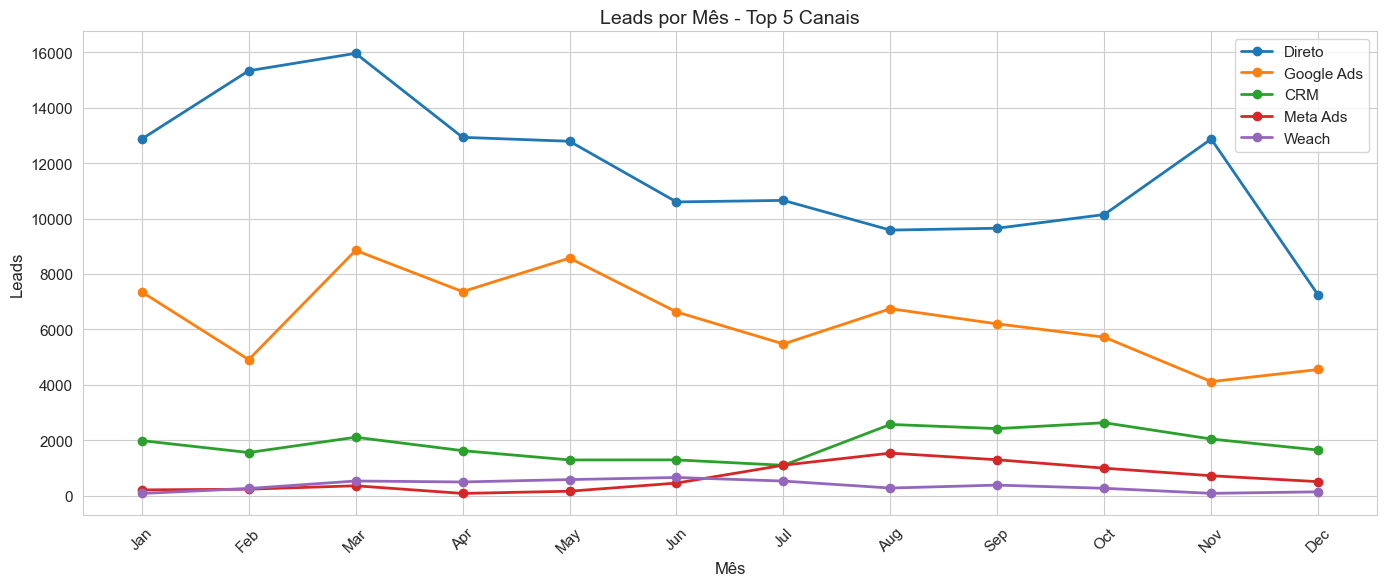

In [24]:
# Leads por mês - top 5 canais
# Desdobra a sazonalidade por canal para entender o que impulsiona os picos e vales

top5 = df_pivot.groupby('canal')['leads'].sum().nlargest(5).index.tolist()

leads_canal_mes = df_pivot[df_pivot['canal'].isin(top5)].groupby(
    ['mes', 'canal']
)['leads'].sum().reset_index()

# Meses fixos 1-12 para manter eixo X alinhado entre canais
meses_fixos = list(range(1, 13))
meses_labels = pd.to_datetime(meses_fixos, format='%m').strftime('%b')

fig, ax = plt.subplots(figsize=(14, 6))
for canal in top5:
    dados = leads_canal_mes[leads_canal_mes['canal'] == canal]
    # Reindexar para garantir todos os 12 meses (preenche com 0 se ausente)
    dados_completo = dados.set_index('mes').reindex(meses_fixos, fill_value=0)
    ax.plot(meses_labels, dados_completo['leads'].values, marker='o', linewidth=2, label=canal)

ax.set_title('Leads por Mês - Top 5 Canais')
ax.set_xlabel('Mês')
ax.set_ylabel('Leads')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 10. Performance por Tipo de Campanha (Canais Pagos)

Dentro de canais pagos, qual tipo de campanha performa melhor em cada etapa do funil?

**O que está sendo feito:**
- Comparação entre tipos pagos considerando volume, conversão e equilíbrio escala-eficiência.

**Por que isso importa:**
- Orienta realocação de verba para tipos com melhor retorno esperado.


In [25]:
# Entender quais estratégias de mídia paga convertem melhor em cada etapa

df_pago = df_pivot[df_pivot['grupo'] == 'Pago'].copy()

pago_tipo = df_pago.groupby('tipo_campanha').agg(
    impressoes=('impressoes', 'sum'),
    cliques=('cliques', 'sum'),
    sessoes=('sessoes', 'sum'),
    leads=('leads', 'sum'),
    apps_pagos=('apps_pagos', 'sum'),
    investimento_brl=('investimento_brl', 'sum'),
).reset_index()

# Métricas derivadas
pago_tipo['ctr'] = safe_div(pago_tipo['cliques'], pago_tipo['impressoes'])
pago_tipo['cvr_sessao_lead'] = safe_div(pago_tipo['leads'], pago_tipo['sessoes'])
pago_tipo['cvr_lead_app'] = safe_div(pago_tipo['apps_pagos'], pago_tipo['leads'])
pago_tipo['cpl'] = safe_div(pago_tipo['investimento_brl'], pago_tipo['leads'])
pago_tipo['cpa'] = safe_div(pago_tipo['investimento_brl'], pago_tipo['apps_pagos'])

# Filtrar tipos com volume mínimo relevante (>= 10 leads)
pago_tipo_relevante = pago_tipo[pago_tipo['leads'] >= 10].sort_values('leads', ascending=False)

print(f"Tipos pagos com >= 10 leads: {len(pago_tipo_relevante)}\n")
print(pago_tipo_relevante[
    ['tipo_campanha', 'leads', 'apps_pagos', 'investimento_brl', 'cvr_lead_app', 'cpl', 'cpa']
].to_string(index=False, float_format='{:,.2f}'.format))

Tipos pagos com >= 10 leads: 25

                      tipo_campanha     leads  apps_pagos  investimento_brl  cvr_lead_app   cpl    cpa
      Google Search Geral Aquisição 31,479.00    8,580.00         21,722.53          0.27  0.69   2.53
    Google Search Branded Aquisição 24,268.00    6,685.00              0.00          0.28  0.00   0.00
    Google Search Geral Remarketing  8,887.00    2,255.00            356.96          0.25  0.04   0.16
Google Search Non Branded Aquisição  5,267.00    1,328.00              0.00          0.25  0.00   0.00
              Google PMax Aquisição  4,845.00      974.00        341,297.43          0.20 70.44 350.41
                    Weach Aquisição  4,389.00    1,037.00        196,483.08          0.24 44.77 189.47
     Facebook Conversão Remarketing  4,001.00      903.00              0.00          0.23  0.00   0.00
       Facebook Conversão Aquisição  3,560.00      575.00              0.00          0.16  0.00   0.00
         Google Display Remarketing  1,1

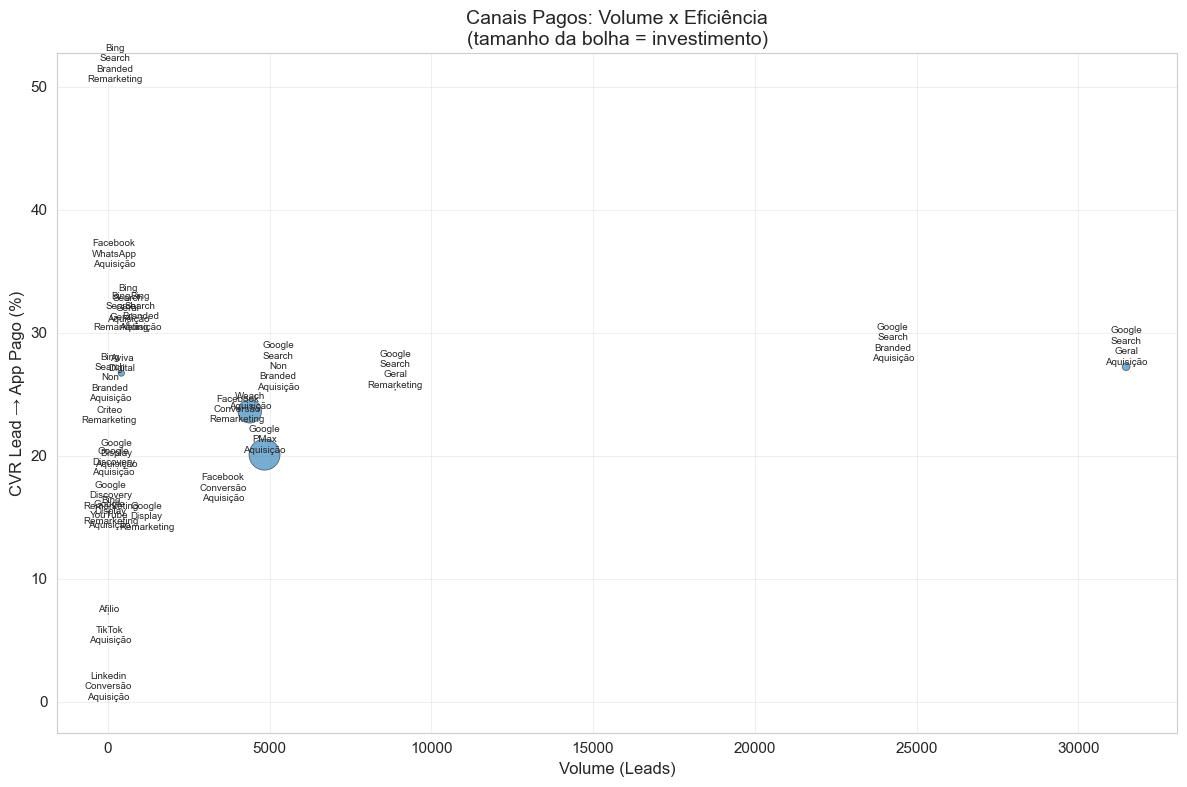

In [26]:
# Scatter: Volume (leads) x Eficiência (CVR lead→app) - canais pagos
# Tamanho da bolha = investimento. Ideal: alto volume + alta conversão (canto superior direito)

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    pago_tipo_relevante['leads'],
    pago_tipo_relevante['cvr_lead_app'] * 100,
    s=pago_tipo_relevante['investimento_brl'] / pago_tipo_relevante['investimento_brl'].max() * 500,
    alpha=0.6, edgecolors='black', linewidth=0.5
)

# Anotar os pontos com o nome do tipo de campanha
for _, row in pago_tipo_relevante.iterrows():
    ax.annotate(
        row['tipo_campanha'].replace(' ', '\n'),
        (row['leads'], row['cvr_lead_app'] * 100),
        fontsize=7, ha='center', va='bottom'
    )

ax.set_xlabel('Volume (Leads)')
ax.set_ylabel('CVR Lead → App Pago (%)')
ax.set_title('Canais Pagos: Volume x Eficiência\n(tamanho da bolha = investimento)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Análise de Correlação

- Investigação de relações entre variáveis usando Pearson (linearidade) e Spearman (monotonicidade) como complemento de robustez. 

- Amostra de 12 meses: resultados indicam tendência, não comprovam causalidade.

### 11.1 Investimento x Apps Pagos

Pearson:  r=-0.383, p-value=0.2197
Spearman: r=-0.434, p-value=0.1591
N = 12 meses
Nota: amostra pequena (12 meses) - interpretar coeficientes com cautela.


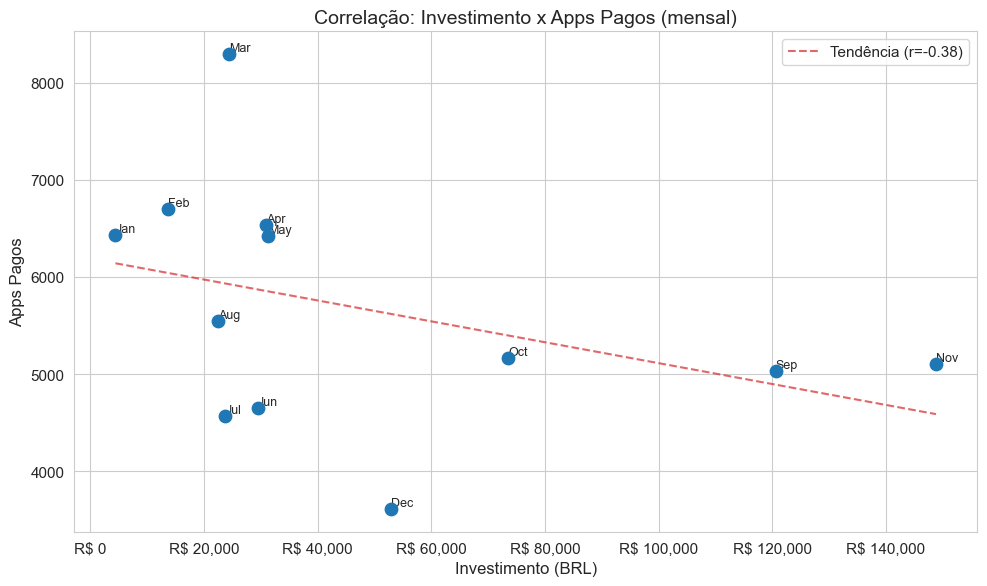

In [34]:
corr_mes = df_pivot.groupby('mes').agg(
    investimento_brl=('investimento_brl', 'sum'),
    apps_pagos=('apps_pagos', 'sum'),
).reset_index()

pearson_r, pearson_p = stats.pearsonr(corr_mes['investimento_brl'], corr_mes['apps_pagos'])
spearman_r, spearman_p = stats.spearmanr(corr_mes['investimento_brl'], corr_mes['apps_pagos'])

print(f"Pearson:  r={pearson_r:.3f}, p-value={pearson_p:.4f}")
print(f"Spearman: r={spearman_r:.3f}, p-value={spearman_p:.4f}")
print(f"N = {len(corr_mes)} meses")
print("Nota: amostra pequena (12 meses) - interpretar coeficientes com cautela.")

# Scatter com linha de tendência
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(corr_mes['investimento_brl'], corr_mes['apps_pagos'], s=80, zorder=5)

z = np.polyfit(corr_mes['investimento_brl'], corr_mes['apps_pagos'], 1)
p = np.poly1d(z)
x_line = np.linspace(corr_mes['investimento_brl'].min(), corr_mes['investimento_brl'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='tab:red', alpha=0.7, label=f'Tendência (r={pearson_r:.2f})')

# Anotar cada ponto com o nome do mês
nomes_meses = pd.to_datetime(corr_mes['mes'], format='%m').dt.strftime('%b')
for i, row in corr_mes.iterrows():
    ax.annotate(nomes_meses.iloc[i], (row['investimento_brl'], row['apps_pagos']),
                fontsize=9, ha='left', va='bottom')

ax.set_xlabel('Investimento (BRL)')
ax.set_ylabel('Apps Pagos')
ax.set_title('Correlação: Investimento x Apps Pagos (mensal)')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
plt.tight_layout()
plt.show()

### 11.2 Investimento x Custo por Lead (CPL)

Pearson:  r=0.989, p-value=0.0000
Spearman: r=0.944, p-value=0.0000
N = 12 meses
Nota: amostra pequena - interpretar coeficientes com cautela.


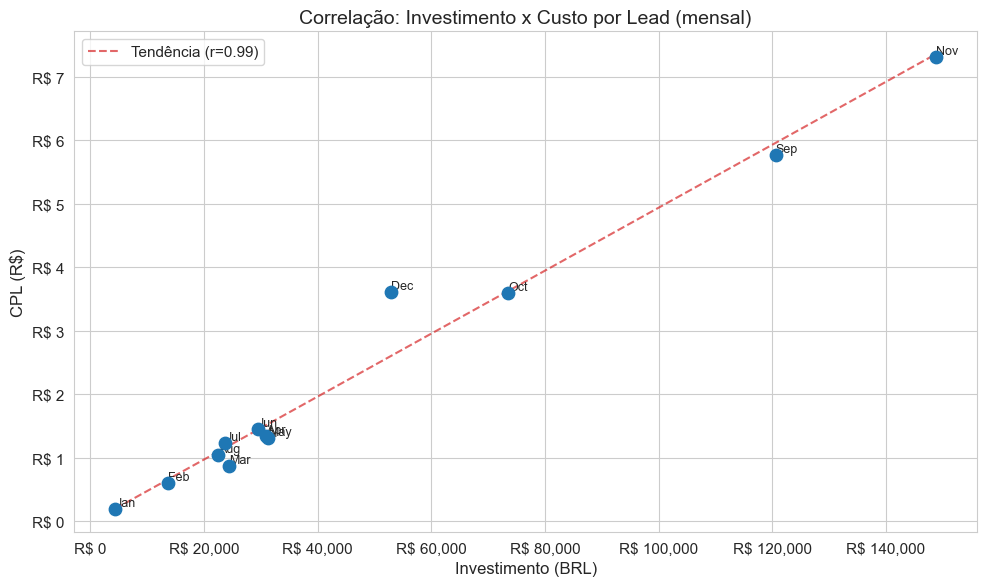

In [35]:
# Agregar leads por mês e fazer merge (evita dependência de ordem)
leads_mes = df_pivot.groupby('mes')['leads'].sum().reset_index()
corr_mes = corr_mes.merge(leads_mes, on='mes', how='left')
corr_mes['cpl'] = safe_div(corr_mes['investimento_brl'].values, corr_mes['leads'].values)

# Filtrar meses com investimento > 0
corr_cpl = corr_mes[corr_mes['investimento_brl'] > 0].copy()

pearson_r, pearson_p = stats.pearsonr(corr_cpl['investimento_brl'], corr_cpl['cpl'])
spearman_r, spearman_p = stats.spearmanr(corr_cpl['investimento_brl'], corr_cpl['cpl'])

print(f'Pearson:  r={pearson_r:.3f}, p-value={pearson_p:.4f}')
print(f'Spearman: r={spearman_r:.3f}, p-value={spearman_p:.4f}')
print(f'N = {len(corr_cpl)} meses')
print("Nota: amostra pequena - interpretar coeficientes com cautela.")

# Scatter com linha de tendência
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(corr_cpl['investimento_brl'], corr_cpl['cpl'], s=80, zorder=5)

z = np.polyfit(corr_cpl['investimento_brl'], corr_cpl['cpl'], 1)
p = np.poly1d(z)
x_line = np.linspace(corr_cpl['investimento_brl'].min(), corr_cpl['investimento_brl'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='tab:red', alpha=0.7, label=f'Tendência (r={pearson_r:.2f})')

nomes_meses = pd.to_datetime(corr_cpl['mes'], format='%m').dt.strftime('%b')
for i, (_, row) in enumerate(corr_cpl.iterrows()):
    ax.annotate(nomes_meses.iloc[i], (row['investimento_brl'], row['cpl']),
                fontsize=9, ha='left', va='bottom')

ax.set_xlabel('Investimento (BRL)')
ax.set_ylabel('CPL (R$)')
ax.set_title('Correlação: Investimento x Custo por Lead (mensal)')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
plt.tight_layout()
plt.show()

### 11.3 Conquistados: Search x Direto

Testa a hipótese de efeito halo: quando Search sobe, Direto tende a acompanhar?

Pearson:  r=0.263, p-value=0.4085
Spearman: r=0.203, p-value=0.5273
N = 12 meses
Nota: amostra pequena - interpretar como indício, não como prova de causalidade.


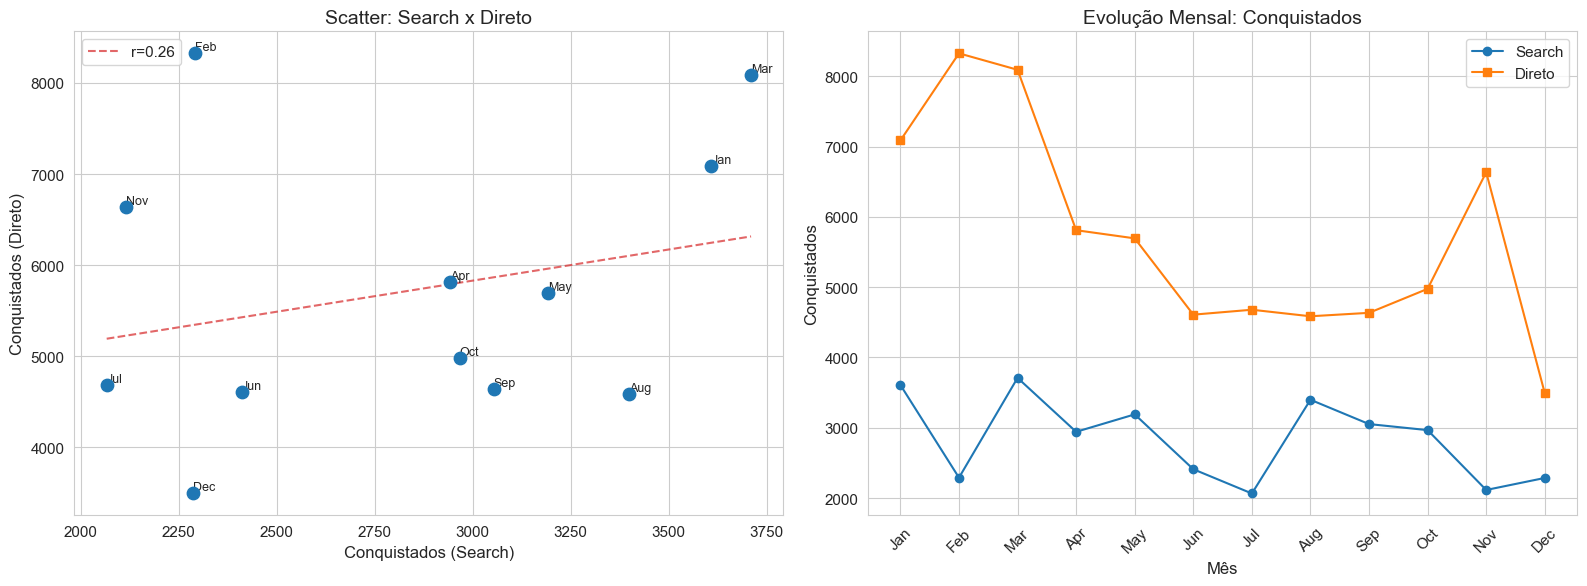

In [36]:
# Filtrar Search: tipo_campanha contém 'Search'
df_search = df_pivot[df_pivot['tipo_campanha'].str.contains('Search', na=False)]
search_mes = df_search.groupby('mes')['conquistados'].sum().reset_index()
search_mes.columns = ['mes', 'conquistados_search']

# Filtrar Direto: canal == 'Direto'
df_direto = df_pivot[df_pivot['canal'] == 'Direto']
direto_mes = df_direto.groupby('mes')['conquistados'].sum().reset_index()
direto_mes.columns = ['mes', 'conquistados_direto']

# Merge
corr_sd = search_mes.merge(direto_mes, on='mes')

pearson_r, pearson_p = stats.pearsonr(corr_sd['conquistados_search'], corr_sd['conquistados_direto'])
spearman_r, spearman_p = stats.spearmanr(corr_sd['conquistados_search'], corr_sd['conquistados_direto'])

print(f"Pearson:  r={pearson_r:.3f}, p-value={pearson_p:.4f}")
print(f"Spearman: r={spearman_r:.3f}, p-value={spearman_p:.4f}")
print(f"N = {len(corr_sd)} meses")
print("Nota: amostra pequena - interpretar como indício, não como prova de causalidade.")

# Dois gráficos lado a lado: scatter + série temporal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scatter com tendência
ax1.scatter(corr_sd['conquistados_search'], corr_sd['conquistados_direto'], s=80, zorder=5)
z = np.polyfit(corr_sd['conquistados_search'], corr_sd['conquistados_direto'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(corr_sd['conquistados_search'].min(), corr_sd['conquistados_search'].max(), 100)
ax1.plot(x_line, p_fit(x_line), '--', color='tab:red', alpha=0.7, label=f'r={pearson_r:.2f}')

nomes = pd.to_datetime(corr_sd['mes'], format='%m').dt.strftime('%b')
for i, row in corr_sd.iterrows():
    ax1.annotate(nomes.iloc[i], (row['conquistados_search'], row['conquistados_direto']),
                fontsize=9, ha='left', va='bottom')
ax1.set_xlabel('Conquistados (Search)')
ax1.set_ylabel('Conquistados (Direto)')
ax1.set_title('Scatter: Search x Direto')
ax1.legend()

# Série temporal
ax2.plot(nomes, corr_sd['conquistados_search'].values, marker='o', label='Search')
ax2.plot(nomes, corr_sd['conquistados_direto'].values, marker='s', label='Direto')
ax2.set_title('Evolução Mensal: Conquistados')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Conquistados')
ax2.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

---
## 12. Análises Extras

Análises complementares de eficiência e alocação para enriquecer as recomendações.

### 12.1 Eficiência de Verba: Pareto do Investimento

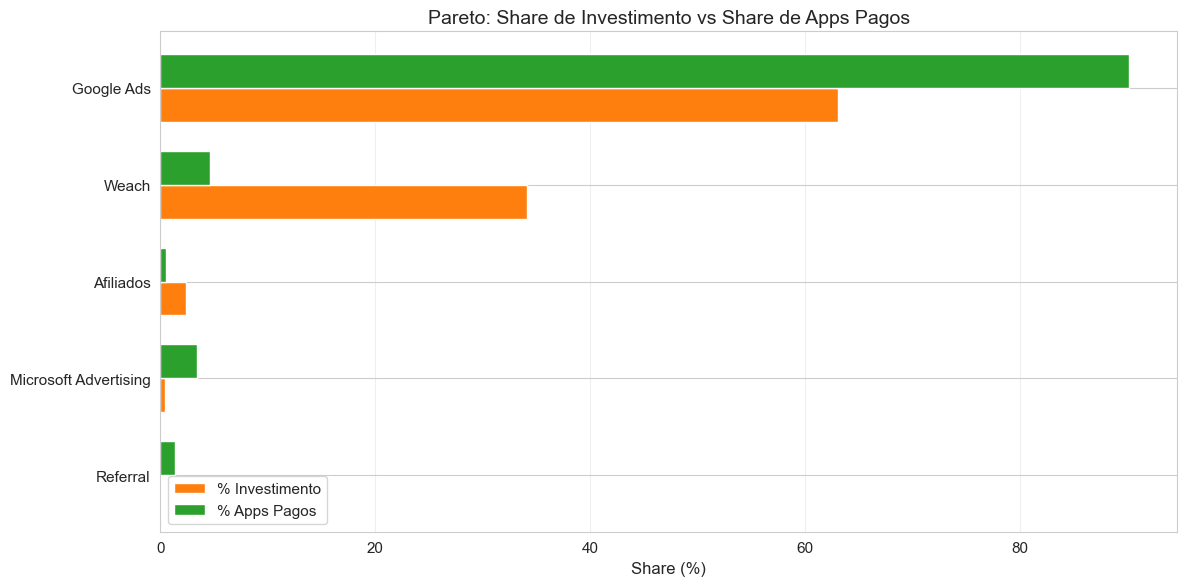

In [30]:

pareto = canal_agg[canal_agg['investimento_brl'] > 0][['canal', 'investimento_brl', 'apps_pagos']].copy()
pareto['share_inv'] = pareto['investimento_brl'] / pareto['investimento_brl'].sum() * 100
pareto['share_apps'] = pareto['apps_pagos'] / pareto['apps_pagos'].sum() * 100
pareto = pareto.sort_values('share_inv', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = range(len(pareto))
width = 0.35

ax.barh([y - width/2 for y in y_pos], pareto['share_inv'].values,
        width, label='% Investimento', color='tab:orange')
ax.barh([y + width/2 for y in y_pos], pareto['share_apps'].values,
        width, label='% Apps Pagos', color='tab:green')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(pareto['canal'].values)
ax.set_xlabel('Share (%)')
ax.set_title('Pareto: Share de Investimento vs Share de Apps Pagos')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 12.2 CPA por Canal

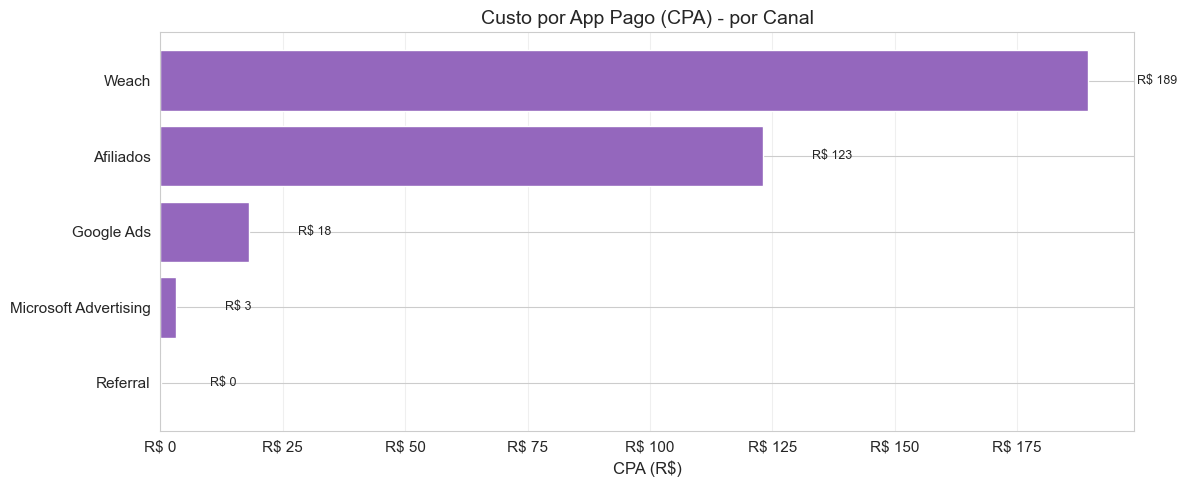

In [37]:
# Menor CPA = canal mais eficiente na conversão final

cpa_canal = canal_agg[
    (canal_agg['investimento_brl'] > 0) & (canal_agg['apps_pagos'] > 0)
][['canal', 'cpa']].sort_values('cpa', ascending=True)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(cpa_canal['canal'], cpa_canal['cpa'], color='tab:purple')
ax.set_xlabel('CPA (R$)')
ax.set_title('Custo por App Pago (CPA) - por Canal')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.grid(True, alpha=0.3, axis='x')

# Anotar valores nas barras
for i, (_, row) in enumerate(cpa_canal.iterrows()):
    ax.text(row['cpa'] + 10, i, f"R$ {row['cpa']:,.0f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 12.3 Evolução do Investimento e ROI ao longo do Ano

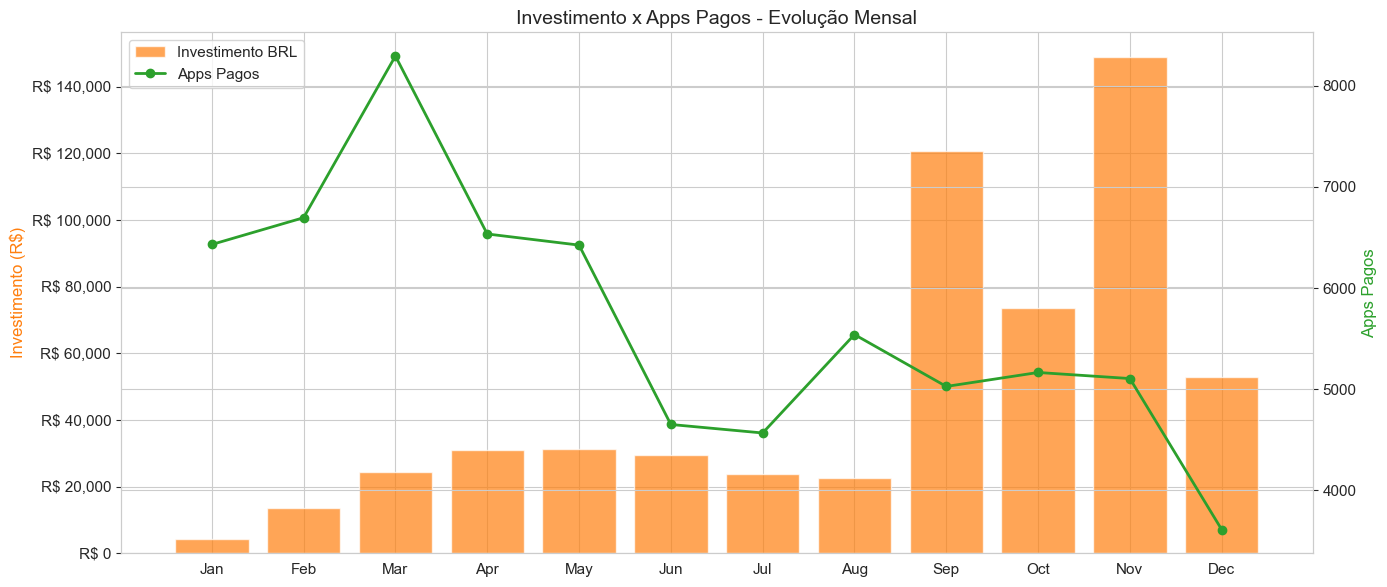

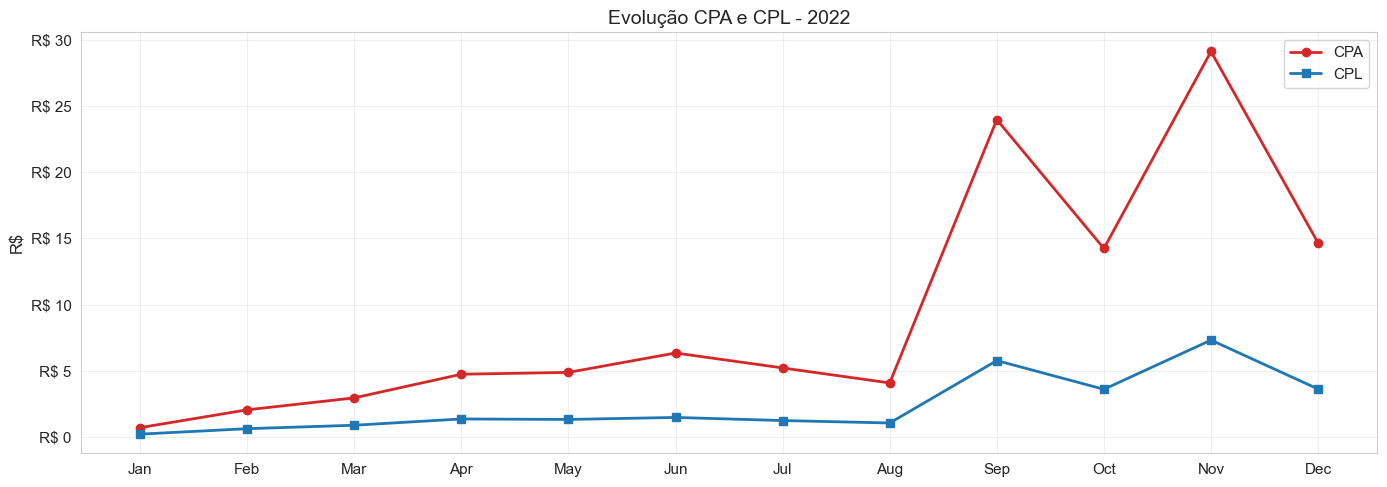

In [ ]:

evo_mes = df_pivot.groupby('mes').agg(
    investimento_brl=('investimento_brl', 'sum'),
    apps_pagos=('apps_pagos', 'sum'),
    leads=('leads', 'sum'),
).reset_index()

evo_mes['cpa'] = safe_div(evo_mes['investimento_brl'].values, evo_mes['apps_pagos'].values)
evo_mes['cpl'] = safe_div(evo_mes['investimento_brl'].values, evo_mes['leads'].values)
nomes_meses = pd.to_datetime(evo_mes['mes'], format='%m').dt.strftime('%b')

# Gráfico 1: Investimento (barras) + Apps Pagos (linha)
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(nomes_meses, evo_mes['investimento_brl'], color='tab:orange', alpha=0.7, label='Investimento BRL')
ax1.set_ylabel('Investimento (R$)', color='tab:orange')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(nomes_meses, evo_mes['apps_pagos'], color='tab:green', marker='o', linewidth=2, label='Apps Pagos')
ax2.set_ylabel('Apps Pagos', color='tab:green')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Investimento x Apps Pagos - Evolução Mensal')
plt.tight_layout()
plt.show()

# Gráfico 2: CPA e CPL mensais - tendência de eficiência
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(nomes_meses, evo_mes['cpa'], marker='o', linewidth=2, label='CPA', color='tab:red')
ax.plot(nomes_meses, evo_mes['cpl'], marker='s', linewidth=2, label='CPL', color='tab:blue')
ax.set_ylabel('R$')
ax.set_title('Evolução CPA e CPL - 2022')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 13. Resumo Executivo - Números Chave

**O que está sendo feito:**
- Consolidação dos principais indicadores globais de volume, conversão e custo.

**Por que isso importa:**
- Entrega visão objetiva para comunicação executiva e comparação rápida de cenário.


In [33]:
# Consolidação dos principais indicadores para visão rápida dos resultados

totais = df_pivot[metricas_funil + ['investimento_brl', 'faturamento']].sum()

print('=' * 60)
print('RESUMO EXECUTIVO - 2022')
print('=' * 60)

print(f"\nFUNIL DE AQUISIÇÃO:")
for i, (metrica, label) in enumerate(zip(metricas_funil, labels_funil)):
    valor = totais[metrica]
    print(f"  {label:<20s}: {valor:>10,.0f}")
    if i > 0:
        anterior = totais[metricas_funil[i-1]]
        taxa = valor / anterior * 100 if anterior > 0 else 0
        print(f"    {'CVR':<18s}: {taxa:>9.1f}%")

leads_total = totais['leads']
apps_total = totais['apps_pagos']
inv_total = totais['investimento_brl']

cpl_geral = inv_total / leads_total if leads_total > 0 else 0
cpa_geral = inv_total / apps_total if apps_total > 0 else 0

print(f"\nFINANCEIRO:")
print(f"  {'Investimento BRL':<20s}: R$ {inv_total:>12,.2f}")
print(f"  {'Faturamento':<20s}: R$ {totais['faturamento']:>12,.2f}")

print(f"\nEFICIÊNCIA:")
print(f"  {'CPL geral':<20s}: R$ {cpl_geral:>10,.2f}")
print(f"  {'CPA geral':<20s}: R$ {cpa_geral:>10,.2f}")
print(f"  {'CVR Lead→App':<20s}: {(apps_total/leads_total*100) if leads_total > 0 else 0:.1f}%")

RESUMO EXECUTIVO - 2022

FUNIL DE AQUISIÇÃO:
  Impressões          : 38,111,501
  Cliques             :    305,990
    CVR               :       0.8%
  Sessões             :  3,136,117
    CVR               :    1024.9%
  Formulários         :    711,848
    CVR               :      22.7%
  Leads               :    258,216
    CVR               :      36.3%
  Atribuídos          :    163,541
    CVR               :      63.3%
  Agendamentos        :    127,775
    CVR               :      78.1%
  Conquistados        :    120,557
    CVR               :      94.4%
  Apps Pagos          :     68,055
    CVR               :      56.5%

FINANCEIRO:
  Investimento BRL    : R$   576,231.35
  Faturamento         : R$ 33,192,000.00

EFICIÊNCIA:
  CPL geral           : R$       2.23
  CPA geral           : R$       8.47
  CVR Lead→App        : 26.4%


---
## 14. Insights Prioritários

1. **Concentração em canais orgânicos**: Direto concentra 55% dos leads e 58% dos apps pagos sem investimento. Canais pagos gastam R&#36; 576 mil para gerar 36% dos leads (CPA médio de R&#36; 24,46).

2. **Gargalo principal**: Lead → Atribuído (63,3%). Cerca de 95 mil leads não são atribuídos. É a maior perda operacional do funil e depende de processo interno, não de mídia.

3. **Investir mais não garante mais conversões**: A correlação entre investimento e apps pagos é fraca e negativa (Pearson r=−0,38, p=0,22). Já a correlação entre investimento e CPL é fortíssima (r=0,99, p<0,001): mais verba encarece o lead.

4. **Eficiência desigual entre tipos pagos**: Google Search Geral tem CPA de R&#36; 2,53, enquanto Google PMax custa R&#36; 350 e Weach R&#36;189 por app pago. Microsoft Advertising (Bing) entrega CPA de R&#36;3,21 com volume relevante.

5. **Search x Direto**: sem evidência de efeito halo. Correlação Pearson r=0,26 (p=0,41) e Spearman r=0,20 (p=0,53). Amostra de 12 meses insuficiente para confirmar co-movimento entre canais.

---
## 15. Recomendações para Growth

1. **Realocar verba para tipos eficientes**: Migrar investimento de Google PMax (CPA R&#36; 350) e Weach (CPA R&#36; 189) para Google Search Geral (CPA R&#36; 2,53) e Bing Search (CPA R&#36; 12,70), que demonstram melhor retorno.

2. **Atacar o gargalo Lead → Atribuído**: Com conversão de 63,3%, ~95 mil leads são perdidos por falta de atribuição. Revisar SLA de atribuição, critérios de qualificação e integração entre marketing e vendas.

3. **Ajustar investimento por sazonalidade**: Concentrar verba nos meses de melhor conversão e reduzir em períodos de queda natural, evitando CPL inflado em meses de baixa demanda.

4. **Fortalecer tracking de campanhas**: 32,7% dos registros (76 mil linhas) vêm de campanhas órfãs sem mapeamento. Padronizar nomenclatura e integrar no dicionário de campanhas para ampliar a confiança analítica.

---
## 16. Conclusão

A Omie apresenta uma base orgânica forte. O canal Direto sozinho entrega 58% dos apps pagos sem custo de mídia. Nos canais pagos, o investimento de R&#36; 576 mil em 2022 gerou 23,5 mil apps com CPA médio de R&#36; 24,46, mas com disparidade relevante entre tipos (de R&#36; 2,53 a R&#36; 350 por app).

O principal ganho potencial não está em aumentar verba (correlação negativa com apps pagos), mas em duas frentes: **realocar investimento** para os tipos de campanha mais eficientes e **corrigir o gargalo operacional** entre Lead e Atribuído, onde 37% dos leads são perdidos antes de serem trabalhados por vendas.